# 13_04 — Evaluación predictiva · Escenario 3

Paso **3b** del ciclo. Supone que `13_03_convergencia` dio veredicto ✓; si las
cadenas no convergieron, nada de lo que sigue significa algo.


## Qué se reporta

| Sección | Qué responde |
|---|---|
| 4 | métricas puntuales y distribucionales, **train vs test** |
| 5 | bandas de credibilidad sobre la serie de cada score |
| 6 | intervalos sobre la curva, en extractos cada 10 períodos |
| 7 | ventana móvil: cómo evoluciona el error al cruzar $T_0$ |
| 8 | calibración marginal: PIT por bloque |
| **9** | **cobertura estratificada por el régimen verdadero** |
| 9.1 | ¿es bimodal la predictiva donde la condicional lo es? |
| 10 | comparación con las líneas base |

Todo el cálculo vive en `fit/` y todo el dibujo en `graphics/`: este notebook
sólo orquesta.

## 1. Imports, rutas y artefactos

In [12]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_curvas_true, cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
    cargar_escenario,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import PSBPPredictor, PropagadorFuncional

from model_psbp_fd.fit import (
    # puntual
    rmse_por_coeficiente, r2_por_columna, razon_dispersion, mise, rmse_funcional,
    # distribucional muestral
    crps_muestral, energy_score, cobertura, intervalo_muestral,
    pit_muestral, diagnostico_pit,
    # calibración condicional al estado verdadero (eje 2 del diseño)
    cobertura_condicional,
    # agrupación de cadenas y ventana móvil
    agrupar_momentos, ventana_movil_scores, ventana_movil_funcional,
)
from model_psbp_fd.graphics import (
    plot_ventana_movil, plot_bandas_serie, plot_extractos_curvas,
    plot_calibracion_pit, plot_scatter_theta,
)
from model_psbp_fd.utils import get_project_root

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [13]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] debe coincidir con 13_01, 13_03 y psbp_fd_iteracion.m
BASENAME, ESCENARIO_ID, REPLICA_ID = "escenario", 3, 1
EXPERIMENT_ID = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,
    "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID,
    "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID,
}
for r in PATHS.values():
    r.mkdir(parents=True, exist_ok=True)
print(f"EXPERIMENT_ID : {EXPERIMENT_ID}")

EXPERIMENT_ID : escenario_3_r01


In [14]:
dfs_train, manifest = cargar_datasets_ar(PATHS, bloque="train")
dfs_test,  _        = cargar_datasets_ar(PATHS, bloque="test")
hp_json     = cargar_hiperparametros(PATHS)
eval_config = cargar_config_evaluacion(PATHS)

COMPONENT_IDX = manifest["component_idx"]
n_components  = len(COMPONENT_IDX)
cov_names     = manifest["cov_names"]
N_LAGS        = int(manifest["n_lags"])
T, T0         = int(manifest["T"]), int(manifest["T0"])
N_ITER        = int(hp_json["n_iter"])
MCMC_CFG      = hp_json["mcmc_config"]
BURN          = int(MCMC_CFG["burn"])

assert manifest["scores_scale"] == "standardized_zscore_ddof0"

# Parámetros de evaluación: se LEEN del artefacto, no se redeclaran aquí.
NIVEL        = float(eval_config.get("nivel_credibilidad", 0.95))
MODO_RESIDUO = eval_config.get("modo_residuo", "ninguno")
OBJETIVO     = eval_config.get("objetivo_evaluacion", "curva_verdadera")
VENTANAS_W   = list(eval_config.get("ventana_movil", {}).get("w", [10, 20, 40]))
ESTRAT_CFG   = eval_config.get("estratificacion", {})
AMB_CFG      = eval_config.get("origenes_ambiguos", {})

print(f"T={T}  T0={T0}  n_lags={N_LAGS}  componentes={n_components}")
print(f"nivel={NIVEL}  ·  modo_residuo={MODO_RESIDUO!r}  ·  objetivo={OBJETIVO!r}")
print(f"ventanas w = {VENTANAS_W}")
print(f"estratificación = {ESTRAT_CFG.get('variable', '—')} "
      f"({ESTRAT_CFG.get('metodo', '—')})")

T=400  T0=280  n_lags=1  componentes=3
nivel=0.95  ·  modo_residuo='ninguno'  ·  objetivo='curva_verdadera'
ventanas w = [10, 20, 40]
estratificación = regimen_idx (estado discreto del generador, sin cuantilizar)


In [15]:
fpca = cargar_fpca(PATHS)
_ver = fpca.verificar()
assert _ver["todo_ok"], f"Las identidades FPCA no se cumplen: {_ver}"

scores_standardizer = cargar_estandarizador(PATHS, DataStandardizer)
X_obs, grilla = cargar_curvas(PATHS)                 # (T, G) con ruido
X_true        = cargar_curvas_true(PATHS)            # (T, G) verdadera — el objetivo

M_fpca   = fpca.M
Psi_grid, mu_grid = fpca.Psi_grid, fpca.mu_grid
SCORES     = fpca.SCORES                              # (T, M) escala original
SCORES_STD = scores_standardizer.transform(SCORES)

print(f"FPCA M={M_fpca} K={fpca.K}   ·   curvas {X_true.shape}  grilla {grilla.shape}")
print(f"sd(observada − verdadera) = {(X_obs - X_true).std():.4f}   "
      "← el ruido que el modelo NO debe predecir")
assert COMPONENT_IDX == list(range(M_fpca)), (
    "La propagación funcional necesita el vector completo de scores en orden; "
    f"COMPONENT_IDX={COMPONENT_IDX} y M={M_fpca}.")

FPCA M=3 K=8   ·   curvas (400, 75)  grilla (75,)
sd(observada − verdadera) = 0.2503   ← el ruido que el modelo NO debe predecir


### 1.1 Estado verdadero del generador


In [16]:
_csv_estado = PATHS["out_report"] / "10_estado_regimen.csv"
HAY_P = False
if _csv_estado.exists():
    estado_df = pd.read_csv(_csv_estado)
    regimen   = estado_df["regimen_idx"].to_numpy().astype(int)
    p_reg1    = estado_df["p_regimen1"].to_numpy()
    ambig     = estado_df["ambiguedad"].to_numpy()
    HAY_P     = True
    _fuente   = _csv_estado.name
else:
    _crudo = cargar_escenario(str(PATHS["raw"] / f"escenario_{ESCENARIO_ID}.npz"))
    assert "interno_regimenes" in _crudo, (
        "El .npz no contiene `interno_regimenes`: regenera 13_01 con "
        "guardar_escenario(..., incluir_internos=True).")
    regimen = _crudo["interno_regimenes"][REPLICA_ID - 1].astype(int)
    p_reg1  = np.full(T, np.nan); ambig = np.full(T, np.nan)
    _fuente = f"escenario_{ESCENARIO_ID}.npz::interno_regimenes"
    print("⚠ Sin CSV de estado: §9.1 (bimodalidad) se omitirá.")

J         = int(regimen.max()) + 1
ETIQUETAS = list(ESTRAT_CFG.get("etiquetas", [f"régimen {j+1}" for j in range(J)]))
assert regimen.shape == (T,), f"regimen tiene {regimen.shape}, se esperaba ({T},)"

print(f"estado verdadero leído de {_fuente}   ·   {J} regímenes")
print(f"proporciones globales: "
      f"{[round(float((regimen == j).mean()), 3) for j in range(J)]}")

estado verdadero leído de 10_estado_regimen.csv   ·   2 regímenes
proporciones globales: [0.355, 0.645]


## 2. Trazas MCMC

In [17]:
def ruta_traza(fpc_idx, chain):
    return PATHS["out_artefact"] / f"chain_fpc_{fpc_idx}_iter{chain:02d}.mat"


def leer_traza(path):
    m = loadmat(str(path))
    claves = ["betajhout", "beta0hout", "tauhout", "alphahout", "psijhout",
              "Gammajhout", "gammajhout", "pijout", "wjout", "osumout", "inEout"]
    traces = {k: np.asarray(m[k], dtype=np.float64) for k in claves}
    burn = int(np.asarray(m["burn"]).ravel()[0])
    feat = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
    return traces, burn, feat


class ModeloTraza:
    def __init__(self, traces, burn, feature_names):
        self.traces = traces
        self.feature_names_ = list(feature_names)
        self.burn = int(burn)
        self.predictor_ = PSBPPredictor(traces=traces, burn=burn)

    def _diseno(self, df):
        Xp = np.asarray(df.iloc[:, 1:], dtype=float)
        return np.hstack([np.ones((Xp.shape[0], 1)), Xp])

    def momentos(self, df):
        return self.predictor_.momentos_predictivos(self._diseno(df))

    def muestrear(self, df, d=1, seed=None):
        return self.predictor_.muestrear(self._diseno(df), d, seed=seed)


faltan = [ruta_traza(COMPONENT_IDX[k] + 1, c + 1).name
          for k in range(n_components) for c in range(N_ITER)
          if not ruta_traza(COMPONENT_IDX[k] + 1, c + 1).exists()]
assert not faltan, f"Faltan trazas: {faltan}. Ejecuta psbp_fd_iteracion.m."

models_chains = {k: {} for k in range(n_components)}
for k in range(n_components):
    esperado = list(dfs_train[k].columns[1:])
    for c in range(N_ITER):
        traces, burn, feat = leer_traza(ruta_traza(COMPONENT_IDX[k] + 1, c + 1))
        assert feat == esperado, f"[k={k} c={c+1}] feature_names ≠ columnas del dataset."
        models_chains[k][c] = ModeloTraza(traces, burn, feat)

n_post = MCMC_CFG["nsim"] - BURN
print(f"✓ {n_components} × {N_ITER} cadenas · {n_post} draws posteriores c/u")

✓ 3 × 3 cadenas · 1500 draws posteriores c/u


## 3. Predicción a $h=1$ sobre la serie completa

Los dos bloques se concatenan en **una sola serie de orígenes**
$t=N_{lags}+1,\dots,T$. Ésa es la diferencia con el flujo anterior, que sólo
evaluaba el bloque de prueba: sin el tramo de entrenamiento no hay con qué
comparar el salto en $T_0$, que es la lectura principal de la ventana móvil.

En todos los orígenes la predicción usa los **rezagos reales** —nunca
predicciones encadenadas—, de modo que el horizonte es 1 en todo el recorrido y
el modelo no se reentrena en ningún punto.

In [18]:
# Número de extracciones de la predictiva por draw posterior. El total es
#     S = (nsim - burn) × S_POR_ITER × n_cadenas
# y d=1 ya da varios miles: subirlo sólo reduce el error Monte Carlo de estimar
# los cuantiles, no cambia la predictiva.
#
# [FIX memoria] estaba en 100, que con estos tamaños pedía varios GB para
# `SC_draws` en float64. Con 10 el total son decenas de miles de extracciones,
# error MC del cuantil al 2.5% del orden de 0.002 sd, y el cubo cabe holgado.
S_POR_ITER = 10
SEED_PRED  = 20260823

dfs_full = {k: pd.concat([dfs_train[k], dfs_test[k]], ignore_index=True)
            for k in range(n_components)}
n_orig   = len(dfs_full[0])
t_orig   = np.arange(N_LAGS + 1, T + 1)          # tiempo del experimento, base-1
assert len(t_orig) == n_orig, f"{len(t_orig)} ≠ {n_orig}"

T0_orig  = T0 - N_LAGS
es_train = t_orig <= T0

# Estado verdadero alineado a los orígenes evaluados
reg_ev = regimen[N_LAGS:]
amb_ev = ambig[N_LAGS:]
p_ev   = p_reg1[N_LAGS:]
assert reg_ev.shape[0] == n_orig

print(f"orígenes evaluados: {n_orig}  (train {es_train.sum()} · test {(~es_train).sum()})")
for j in range(J):
    print(f"  {ETIQUETAS[j]:<12} train {int(((reg_ev==j) & es_train).sum()):>4}  "
          f"test {int(((reg_ev==j) & ~es_train).sum()):>4}")

_mem_gb = n_post * S_POR_ITER * N_ITER * n_orig * n_components * 4 / 1e9
print(f"SC_draws reservará {_mem_gb * 1e3:.0f} MB en float32")
assert _mem_gb < 2.0, (
    f"SC_draws pediría {_mem_gb:.1f} GB. Baja S_POR_ITER antes de continuar.")

orígenes evaluados: 399  (train 279 · test 120)
  régimen 1    train   96  test   46
  régimen 2    train  183  test   74
SC_draws reservará 215 MB en float32


In [19]:
# Momentos y extracciones por score, agrupando cadenas.
#   momentos : ley de varianza total entre cadenas (fit.agrupar_momentos)
#   muestras : concatenación, que es la mezcla de igual peso
#
# [FIX memoria] `SC_draws` se PREASIGNA y cada cadena se escribe en su rebanada.
# El patrón anterior (lista → np.concatenate → np.stack) mantenía vivas tres
# copias del cubo a la vez. float32 basta: estos draws sólo alimentan cuantiles,
# CRPS, PIT y la ventana móvil. La propagación funcional recasta a float64.
Y_obs  = np.column_stack([dfs_full[k].iloc[:, 0].to_numpy() for k in range(n_components)])
Y_hat  = np.empty_like(Y_obs)
Y_sd   = np.empty_like(Y_obs)

S_POR_CADENA = n_post * S_POR_ITER
S_total      = S_POR_CADENA * N_ITER
SC_draws     = np.empty((S_total, n_orig, n_components), dtype=np.float32)

for k in range(n_components):
    medias, sds = [], []
    for j, c in enumerate(sorted(models_chains[k])):
        mom = models_chains[k][c].momentos(dfs_full[k])
        medias.append(mom["media"])
        sds.append(mom["sd"])            # PREDICTIVA (v3), no la del centro
        muestras_c = models_chains[k][c].muestrear(
            dfs_full[k], S_POR_ITER, seed=SEED_PRED + 1000 * k + c)
        assert muestras_c.shape == (S_POR_CADENA, n_orig), (
            f"[k={k} c={c}] muestrear devolvió {muestras_c.shape}; se esperaba "
            f"({S_POR_CADENA}, {n_orig}). ¿nsim/burn del .mat difieren del JSON?")
        SC_draws[j * S_POR_CADENA:(j + 1) * S_POR_CADENA, :, k] = muestras_c
        del muestras_c
    Y_hat[:, k], Y_sd[:, k] = agrupar_momentos(np.column_stack(medias),
                                               np.column_stack(sds))

li_s, ls_s = intervalo_muestral(SC_draws, nivel=NIVEL)   # (n_orig, M)

print(f"extracciones por score: S = {S_total} "
      f"= {n_post} draws × {S_POR_ITER} × {N_ITER} cadenas")
print(f"SC_draws {SC_draws.shape} {SC_draws.dtype} "
      f"({SC_draws.nbytes / 1e6:.0f} MB)  ·  bandas {li_s.shape}")

# ¿Qué componente separa los regímenes en la predictiva? Señal temprana del
# resultado de §9.1: la media predicha debería desplazarse con el régimen.
print("\nmedia predicha por régimen (scores estandarizados):")
for k in range(n_components):
    m0, m1 = Y_hat[reg_ev == 0, k].mean(), Y_hat[reg_ev == 1, k].mean()
    print(f"  FPC {COMPONENT_IDX[k]+1}: {ETIQUETAS[0]} {m0:+.3f}   "
          f"{ETIQUETAS[1]} {m1:+.3f}   separación {abs(m1-m0):.3f}")
K_SEP = int(np.argmax([abs(Y_hat[reg_ev == 1, k].mean() - Y_hat[reg_ev == 0, k].mean())
                       for k in range(n_components)]))
print(f"→ componente que más separa los regímenes: FPC {COMPONENT_IDX[K_SEP]+1} "
      f"(se usa en §9.1)")

extracciones por score: S = 45000 = 1500 draws × 10 × 3 cadenas
SC_draws (45000, 399, 3) float32 (215 MB)  ·  bandas (399, 3)

media predicha por régimen (scores estandarizados):
  FPC 1: régimen 1 +0.454   régimen 2 -0.179   separación 0.633
  FPC 2: régimen 1 -0.001   régimen 2 +0.007   separación 0.009
  FPC 3: régimen 1 +0.004   régimen 2 +0.003   separación 0.001
→ componente que más separa los regímenes: FPC 1 (se usa en §9.1)


### 3.1 Propagación a la curva

$\hat X^{(s)}_t(\tau)=\mu(\tau)+\sum_m (d_m\tilde\xi^{(s)}_{tm}+c_m)\psi_m(\tau)$,
que es (3.41) del documento. Con `modo_residuo="ninguno"` el mapa es
determinista y las curvas son extracciones exactas de la predictiva de la curva
**proyectada**.

Las muestras funcionales se **adelgazan** antes de propagar: el arreglo completo
sería $(S, n, G)$ y con $S$ de varios miles ocupa más de un gigabyte sin que los
cuantiles al 95 % mejoren de forma apreciable.

In [20]:
S_FUNC = 500
paso_thin = max(1, S_total // S_FUNC)
SC_thin = SC_draws[::paso_thin]

propagador = PropagadorFuncional(Psi_grid, mu_grid,
                                 estandarizador=scores_standardizer,
                                 modo_residuo=MODO_RESIDUO)
X_draws = propagador.curvas_desde_scores(SC_thin, seed=SEED_PRED)   # (S', n, G)
X_pred  = X_draws.mean(axis=0)                                       # (n, G)
li_f, ls_f = np.quantile(X_draws, (1 - NIVEL) / 2, axis=0), \
             np.quantile(X_draws, 1 - (1 - NIVEL) / 2, axis=0)

X_true_ev = X_true[N_LAGS:]     # (n_orig, G) VERDADERA — contra esto se evalúa
X_obs_ev  = X_obs[N_LAGS:]      # (n_orig, G) observada, sólo para las figuras

print(f"muestras funcionales {X_draws.shape}  (adelgazado 1 de cada {paso_thin})")
print(f"memoria ≈ {X_draws.nbytes / 1e6:.0f} MB")

X_proj = fpca.reconstruct(SCORES)[N_LAGS:]
print(f"\nMISE del TRUNCAMIENTO (proyección FPCA de la curva verdadera): "
      f"{mise(X_true_ev, X_proj, grilla):.6f}")
print("   ← ningún modelo sobre esta representación puede bajar de ahí")

muestras funcionales (500, 399, 75)  (adelgazado 1 de cada 90)
memoria ≈ 120 MB

MISE del TRUNCAMIENTO (proyección FPCA de la curva verdadera): 0.005381
   ← ningún modelo sobre esta representación puede bajar de ahí


## 4. Métricas, entrenamiento contra prueba

La comparación train/test es la que separa el ajuste de la generalización.
En el Escenario 3 —FAR con cambio de régimen, estacionario bajo el mecanismo
probit— **las dos columnas deberían parecerse**: si el test se degrada mucho
hay sobreajuste, y la referencia contra la cual leerlo es la corrida 11.

In [21]:
def _metricas_bloque(mask, etiqueta):
    """Métricas puntuales y distribucionales sobre un subconjunto de orígenes."""
    filas = []
    for k in range(n_components):
        y, p = Y_obs[mask, k], Y_hat[mask, k]
        z    = SC_draws[:, mask, k]
        cob  = cobertura(y, li_s[mask, k], ls_s[mask, k])
        pit  = pit_muestral(y, z)
        filas.append({
            "bloque":  etiqueta,
            "FPC":     f"FPC {COMPONENT_IDX[k] + 1}",
            "RMSE":    float(rmse_por_coeficiente(y[:, None], p[:, None])[0]),
            "R2":      float(r2_por_columna(y[:, None], p[:, None], centrar=True)[0]),
            "sd_ratio": float(razon_dispersion(y[:, None], p[:, None])[0]),
            "CRPS":    float(crps_muestral(y, z).mean()),
            f"Cob{int(NIVEL*100)}": cob["cobertura"],
            "Ancho":   cob["ancho_medio"],
            "PIT_ks":  float(diagnostico_pit(pit)["ks"]),
            "PIT_forma": diagnostico_pit(pit)["forma"],
            "n":       int(mask.sum()),
        })
    return filas

met_df = pd.DataFrame(_metricas_bloque(es_train, "train")
                      + _metricas_bloque(~es_train, "test"))
met_df = met_df.set_index(["bloque", "FPC"])
met_df.to_csv(PATHS["out_report"] / "50_metricas_scores.csv")

_num = [c for c in met_df.columns if met_df[c].dtype.kind == "f"]
display(met_df.style
    .format({c: "{:.4f}" for c in _num})
    .background_gradient(subset=["RMSE", "CRPS"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2"], cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=[f"Cob{int(NIVEL*100)}"], cmap="RdYlGn",
                         vmin=0.80, vmax=1.0)
    .set_caption("Métricas por score y bloque · CRPS y cobertura desde la "
                 "predictiva MUESTRAL"))

_deg = (met_df.loc["test", "RMSE"].mean() / met_df.loc["train", "RMSE"].mean())
print(f"\nRMSE test / RMSE train = {_deg:.3f}"
      + ("   ✓ sin degradación apreciable" if _deg < 1.15
         else "   ← el modelo se degrada fuera de muestra"))
print(f"R2 medio (test) = {met_df.loc['test', 'R2'].mean():+.4f}   "
      "← aquí SÍ debe ser apreciable; ≈ 0 indicaría colapso a la media")


RMSE test / RMSE train = 1.059   ✓ sin degradación apreciable
R2 medio (test) = +0.1603   ← aquí SÍ debe ser apreciable; ≈ 0 indicaría colapso a la media


In [22]:
# Métricas funcionales, contra la curva VERDADERA
filas_f = []
for mask, etq in ((es_train, "train"), (~es_train, "test")):
    dentro = (X_true_ev[mask] >= li_f[mask]) & (X_true_ev[mask] <= ls_f[mask])
    filas_f.append({
        "bloque": etq,
        "MISE":   mise(X_true_ev[mask], X_pred[mask], grilla),
        "RMSE_f": rmse_funcional(X_true_ev[mask], X_pred[mask], grilla),
        "MISE_truncamiento": mise(X_true_ev[mask], X_proj[mask], grilla),
        "energy": energy_score(X_true_ev[mask], X_draws[:, mask, :],
                               max_pares=2000, seed=0),
        f"Cob{int(NIVEL*100)}_puntual": float(dentro.mean()),
        "ancho_medio": float((ls_f[mask] - li_f[mask]).mean()),
        "n": int(mask.sum()),
    })
fun_df = pd.DataFrame(filas_f).set_index("bloque")
fun_df.to_csv(PATHS["out_report"] / "51_metricas_funcionales.csv")

display(fun_df.style.format("{:.6f}", subset=["MISE", "RMSE_f", "MISE_truncamiento"])
        .format("{:.4f}", subset=["energy", f"Cob{int(NIVEL*100)}_puntual", "ancho_medio"])
        .set_caption("Métricas funcionales contra la curva VERDADERA · "
                     "banda sin residuo de representación"))

_frac = fun_df["MISE_truncamiento"] / fun_df["MISE"]
print("\nfracción del MISE atribuible al truncamiento FPCA:")
for b in fun_df.index:
    print(f"  {b:5s}: {_frac[b]:.1%}"
          + ("   ← el techo de la representación domina; subir M rinde más "
             "que mejorar el modelo" if _frac[b] > 0.7 else ""))
print(f"\nLa cobertura es PUNTUAL (cada tau por separado), NO simultánea sobre "
      f"la curva.")

,MISE,RMSE_f,MISE_truncamiento,energy,Cob95_puntual,ancho_medio,n
bloque,,,,,,,
train,2.631796,1.622281,0.005339,8.1054,0.9556,6.4977,279
test,2.603604,1.613569,0.005480,8.1419,0.9677,6.5547,120



fracción del MISE atribuible al truncamiento FPCA:
  train: 0.2%
  test : 0.2%

La cobertura es PUNTUAL (cada tau por separado), NO simultánea sobre la curva.


## 5. Bandas de credibilidad sobre la serie de scores

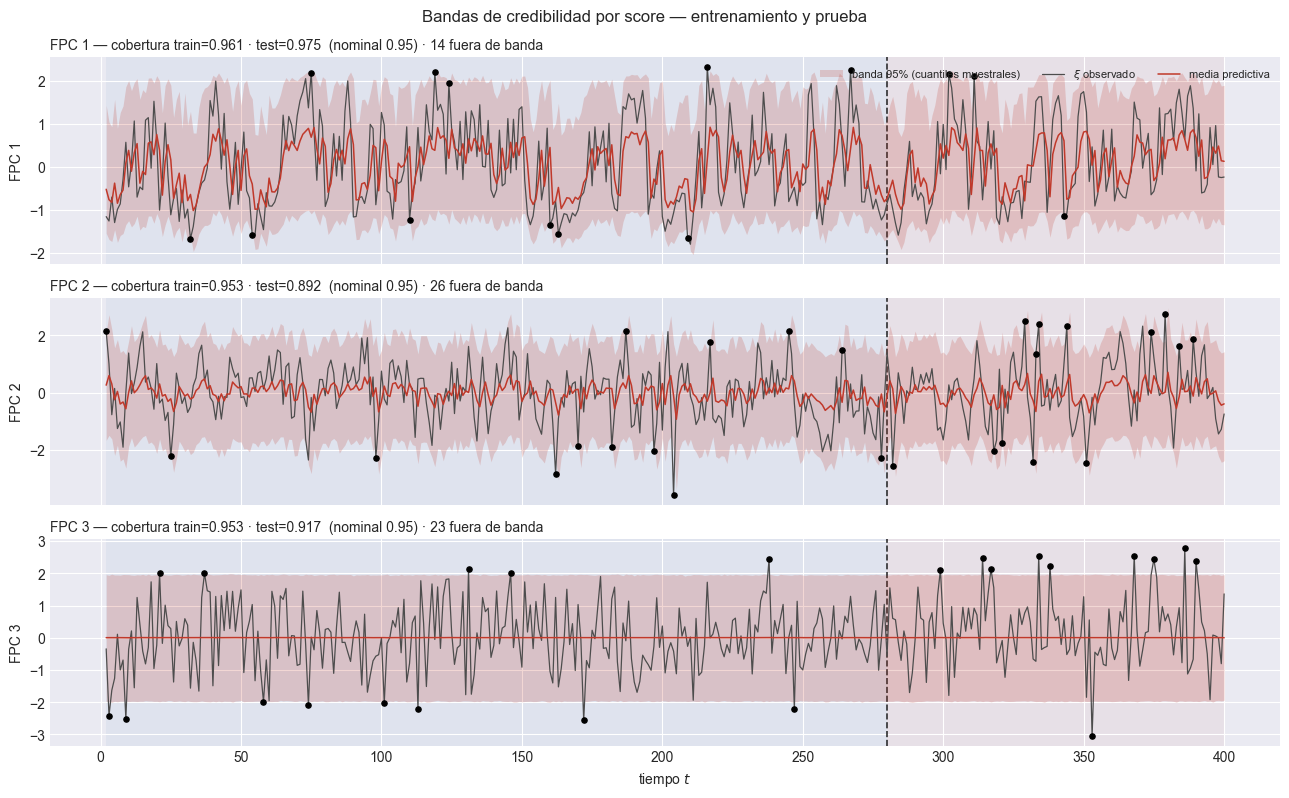

Lectura del escenario: en la componente que carga el régimen, el CENTRO debe saltar
entre dos niveles siguiendo la alternancia, no quedarse en un valor intermedio.


In [23]:
plot_bandas_serie(
    Y_obs, Y_hat, li_s, ls_s, T0, t=t_orig,
    etiquetas=[f"FPC {i + 1}" for i in COMPONENT_IDX], nivel=NIVEL,
    title="Bandas de credibilidad por score — entrenamiento y prueba",
    save_path=str(PATHS["out_report"] / "52_bandas_scores.png"))
plt.show()
print("Lectura del escenario: en la componente que carga el régimen, el CENTRO "
      "debe saltar\nentre dos niveles siguiendo la alternancia, no quedarse "
      "en un valor intermedio.")

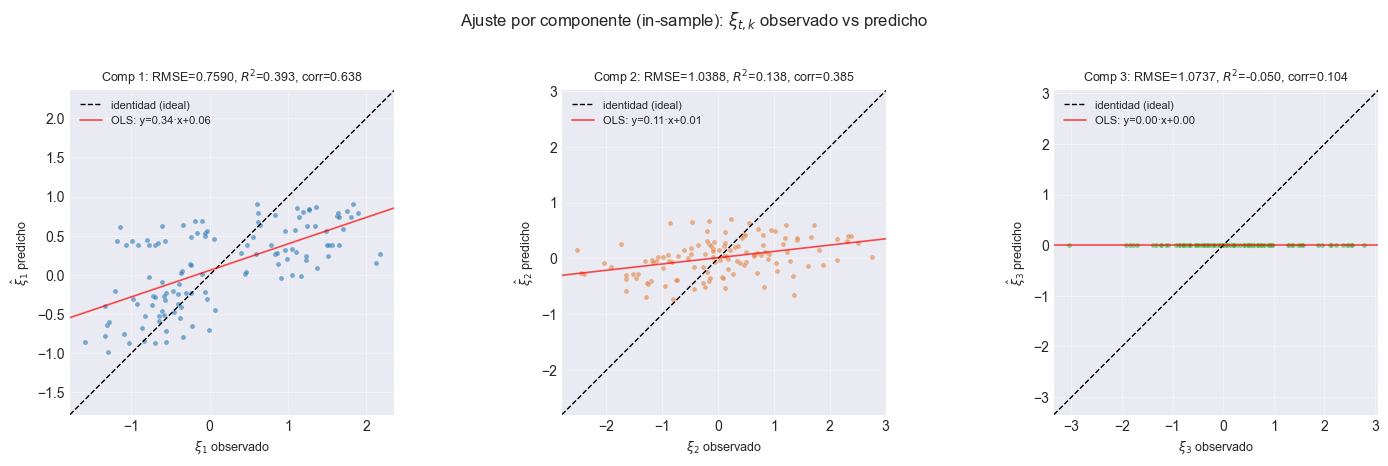

In [24]:
eval_scatter = {k: {"y_obs": Y_obs[~es_train, k], "y_hat": Y_hat[~es_train, k]}
                for k in range(n_components)}
plot_scatter_theta(eval_scatter, n_components=n_components,
                   save_path=str(PATHS["out_report"] / "53_scatter_scores_test.png"))
plt.show()

## 6. Intervalos de credibilidad sobre la curva

Extractos de la serie funcional cada `CADA` períodos, cada uno con su banda
puntual, la curva verdadera y —en gris— los datos observados, para ver de un
vistazo dónde estaba el ruido que la banda **no** tiene que cubrir.

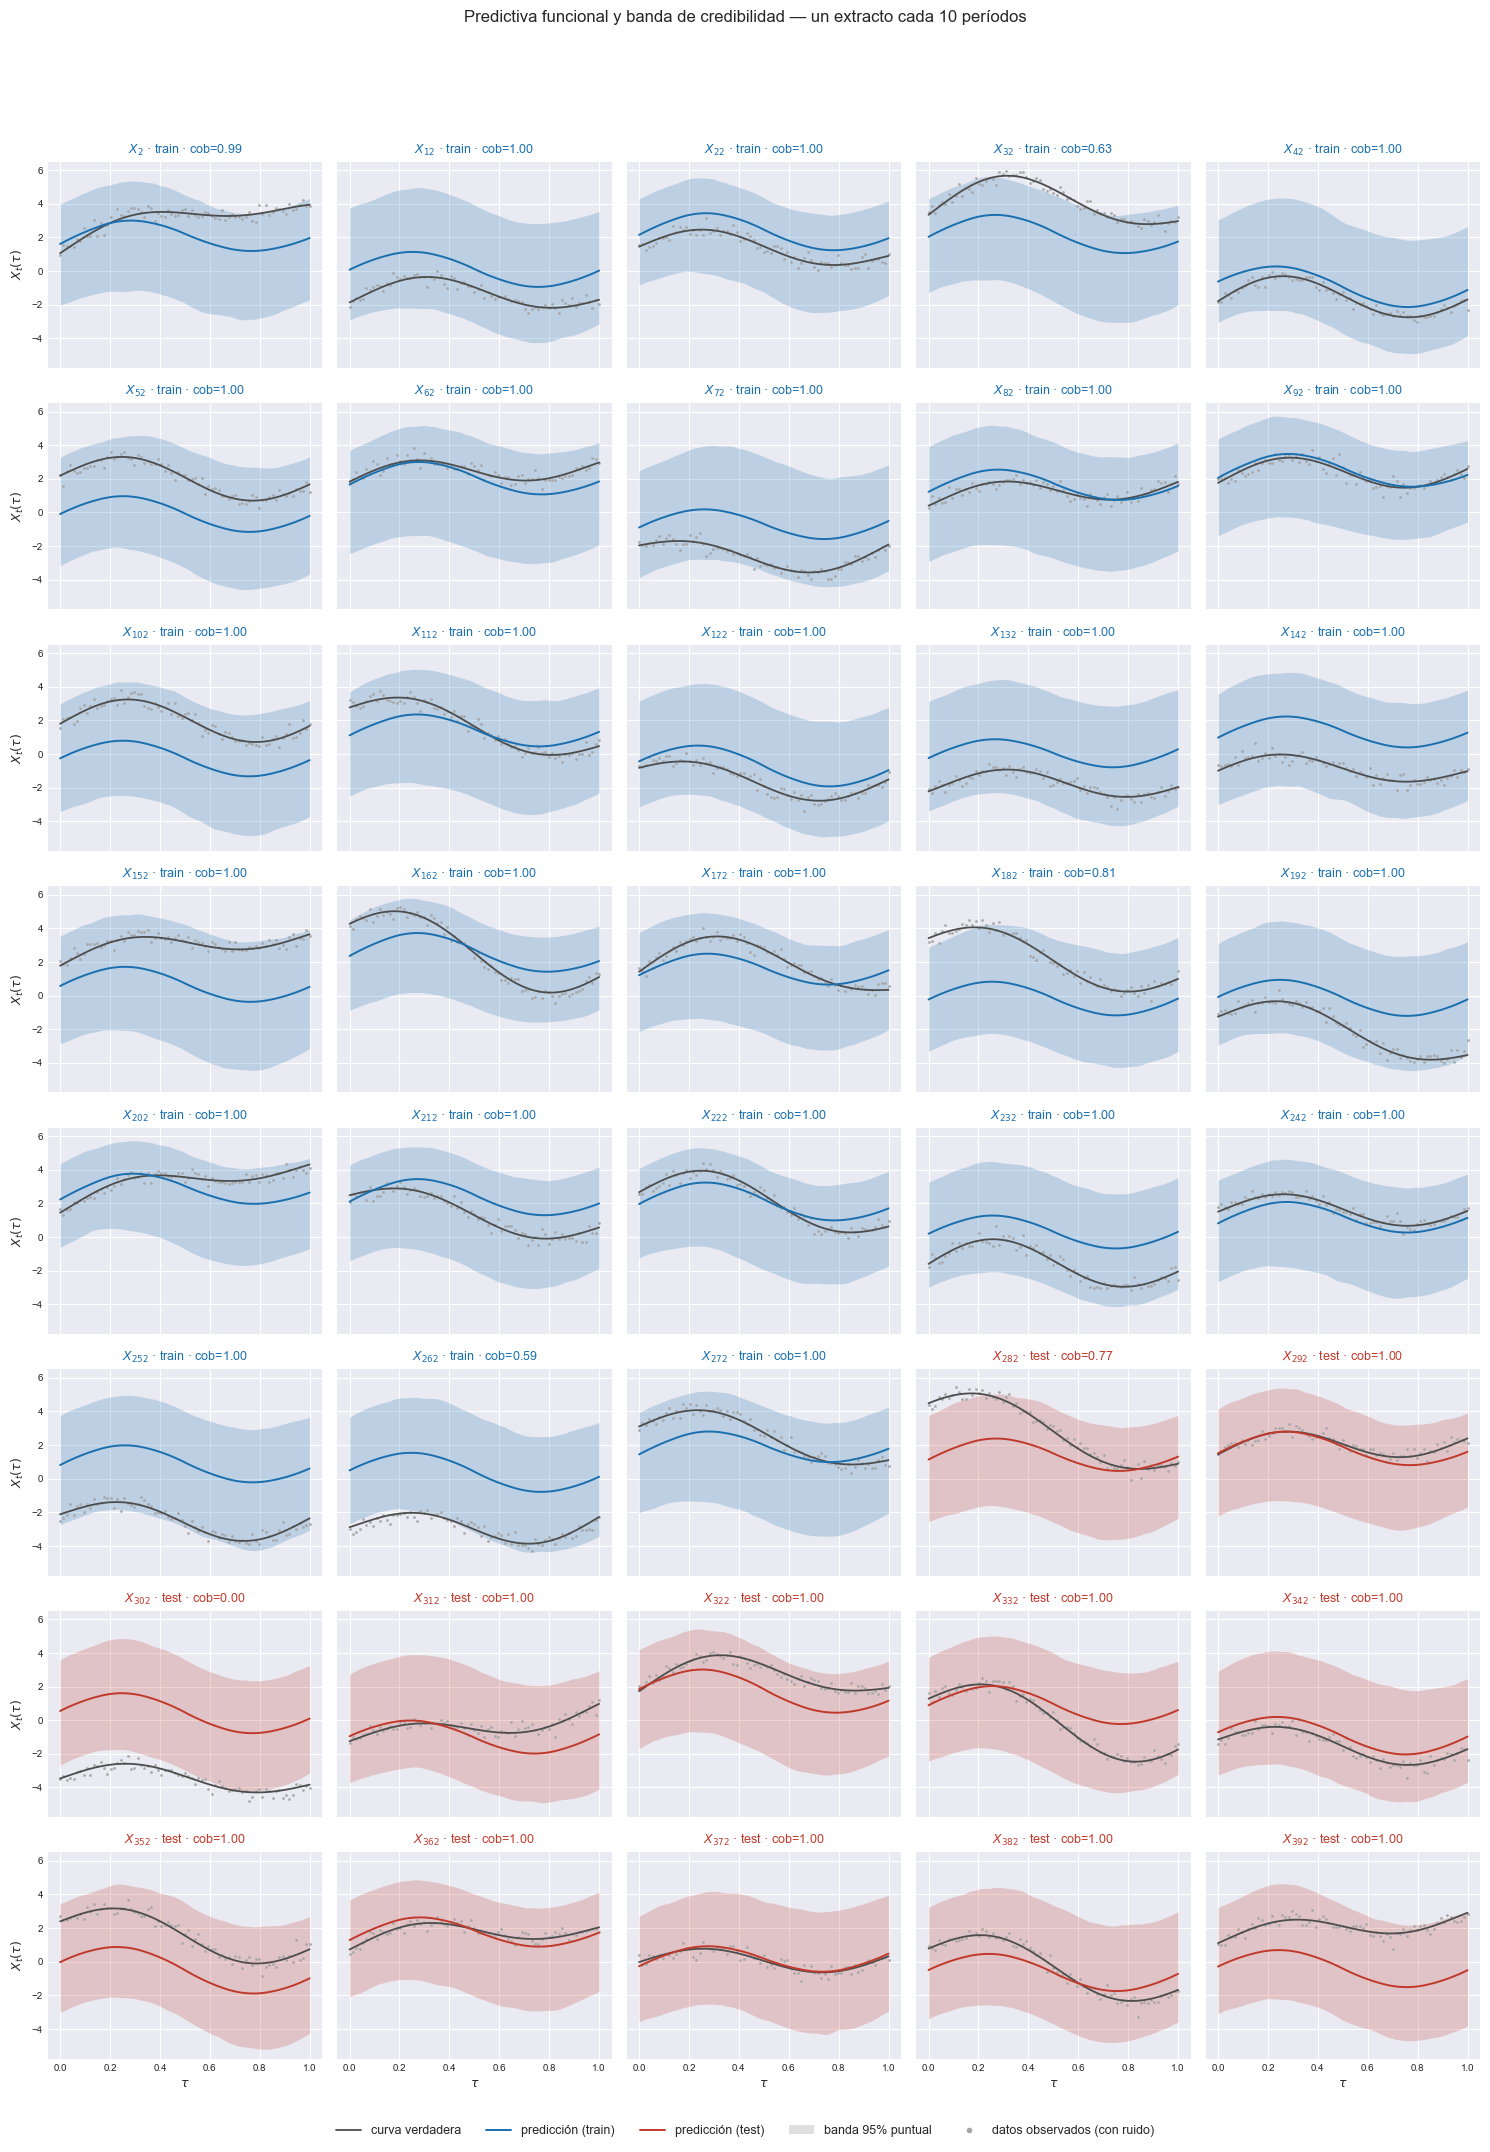

In [25]:
CADA = 10   # [CONFIG] un extracto cada CADA períodos

plot_extractos_curvas(
    X_true_ev, X_pred, li_f, ls_f, grilla, T0, t=t_orig,
    cada=CADA, n_col=5, nivel=NIVEL, X_obs=X_obs_ev,
    title="Predictiva funcional y banda de credibilidad",
    save_path=str(PATHS["out_report"] / "54_extractos_curvas.png"))
plt.show()

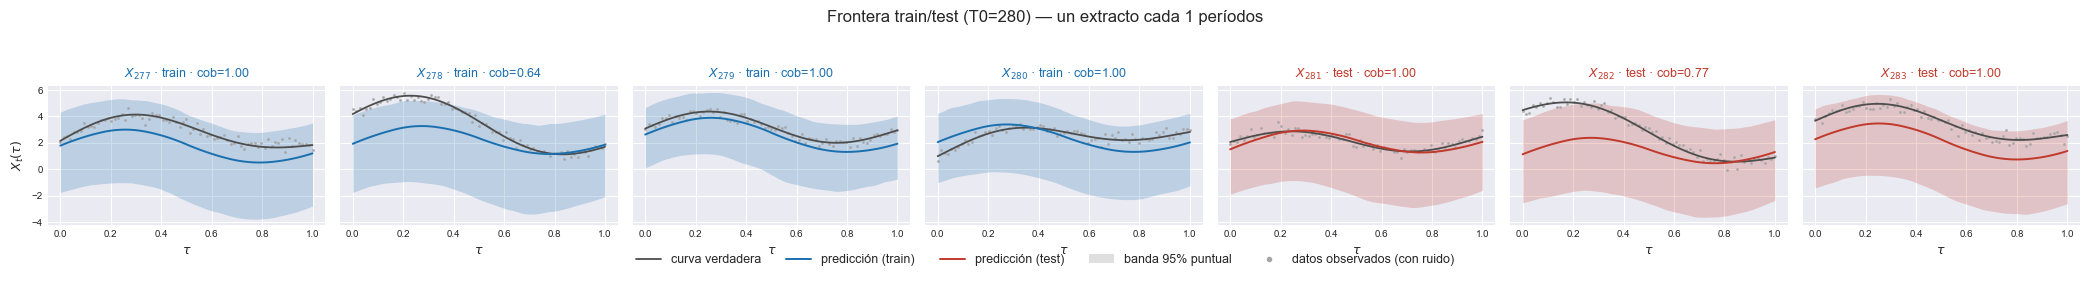

In [26]:
# Zoom sobre la frontera train/test
i_corte = int(np.searchsorted(t_orig, T0))
sel = np.arange(max(0, i_corte - 3), min(n_orig, i_corte + 4))

plot_extractos_curvas(
    X_true_ev[sel], X_pred[sel], li_f[sel], ls_f[sel], grilla, T0,
    t=t_orig[sel], cada=1, n_col=len(sel), nivel=NIVEL, X_obs=X_obs_ev[sel],
    title=f"Frontera train/test (T0={T0})",
    save_path=str(PATHS["out_report"] / "55_extractos_frontera.png"))
plt.show()

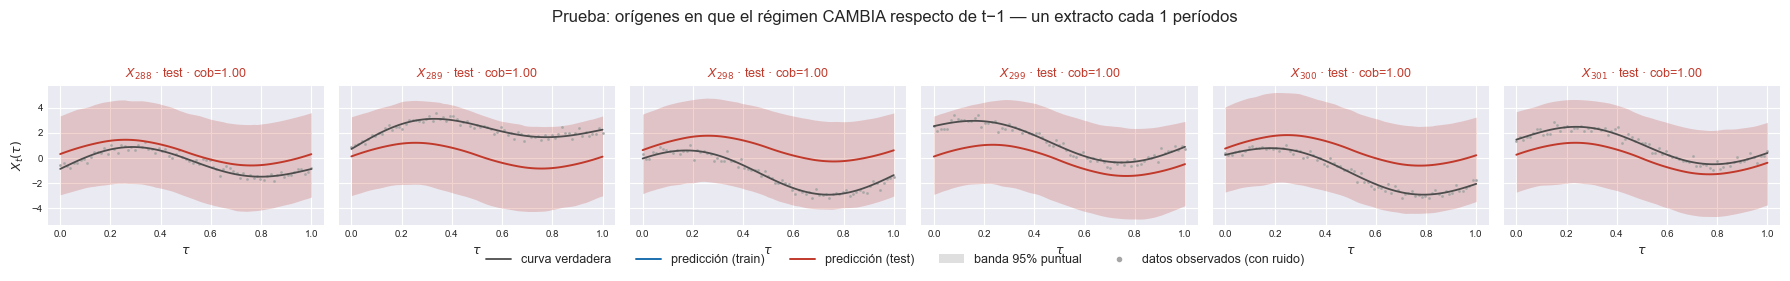

error absoluto medio: en cambios de régimen 1.4877  ·  en todo el test 1.2927  ·  razón 1.15×
   Una razón muy superior a 1 dice que el modelo reacciona con retraso al cambio.


In [27]:
# Extractos elegidos por ESTADO y no por calendario: orígenes de prueba en los
# que el régimen CAMBIA respecto del período anterior. Es donde un modelo que
# no capte el mecanismo se queda con el nivel viejo, y donde la banda tiene que
# ensancharse o desplazarse.
idx_test  = np.where(~es_train)[0]
cambia    = np.concatenate([[False], reg_ev[1:] != reg_ev[:-1]])
sel_camb  = idx_test[cambia[idx_test]][:6]

if sel_camb.size >= 2:
    plot_extractos_curvas(
        X_true_ev[sel_camb], X_pred[sel_camb], li_f[sel_camb], ls_f[sel_camb],
        grilla, T0, t=t_orig[sel_camb], cada=1, n_col=len(sel_camb), nivel=NIVEL,
        X_obs=X_obs_ev[sel_camb],
        title="Prueba: orígenes en que el régimen CAMBIA respecto de t−1",
        save_path=str(PATHS["out_report"] / "56_extractos_cambio_regimen.png"))
    plt.show()
    _e_camb = np.abs(X_true_ev[sel_camb] - X_pred[sel_camb]).mean()
    _e_resto = np.abs(X_true_ev[idx_test] - X_pred[idx_test]).mean()
    print(f"error absoluto medio: en cambios de régimen {_e_camb:.4f}  ·  "
          f"en todo el test {_e_resto:.4f}  ·  razón {_e_camb/_e_resto:.2f}×")
    print("   Una razón muy superior a 1 dice que el modelo reacciona con "
          "retraso al cambio.")
else:
    print("Menos de dos cambios de régimen en el bloque de prueba; se omite la figura.")

## 7. Ventana móvil

El modelo **no se reentrena**: lo que se desliza es la ventana de evaluación.
Cada punto agrega las métricas de $w$ orígenes consecutivos, todos a $h=1$ con
los rezagos reales. Se superponen varios anchos para que la conclusión no
dependa de un $w$ elegido a dedo; las ventanas que **cruzan** $T_0$ van
punteadas, porque su cifra mezcla dentro y fuera de muestra.

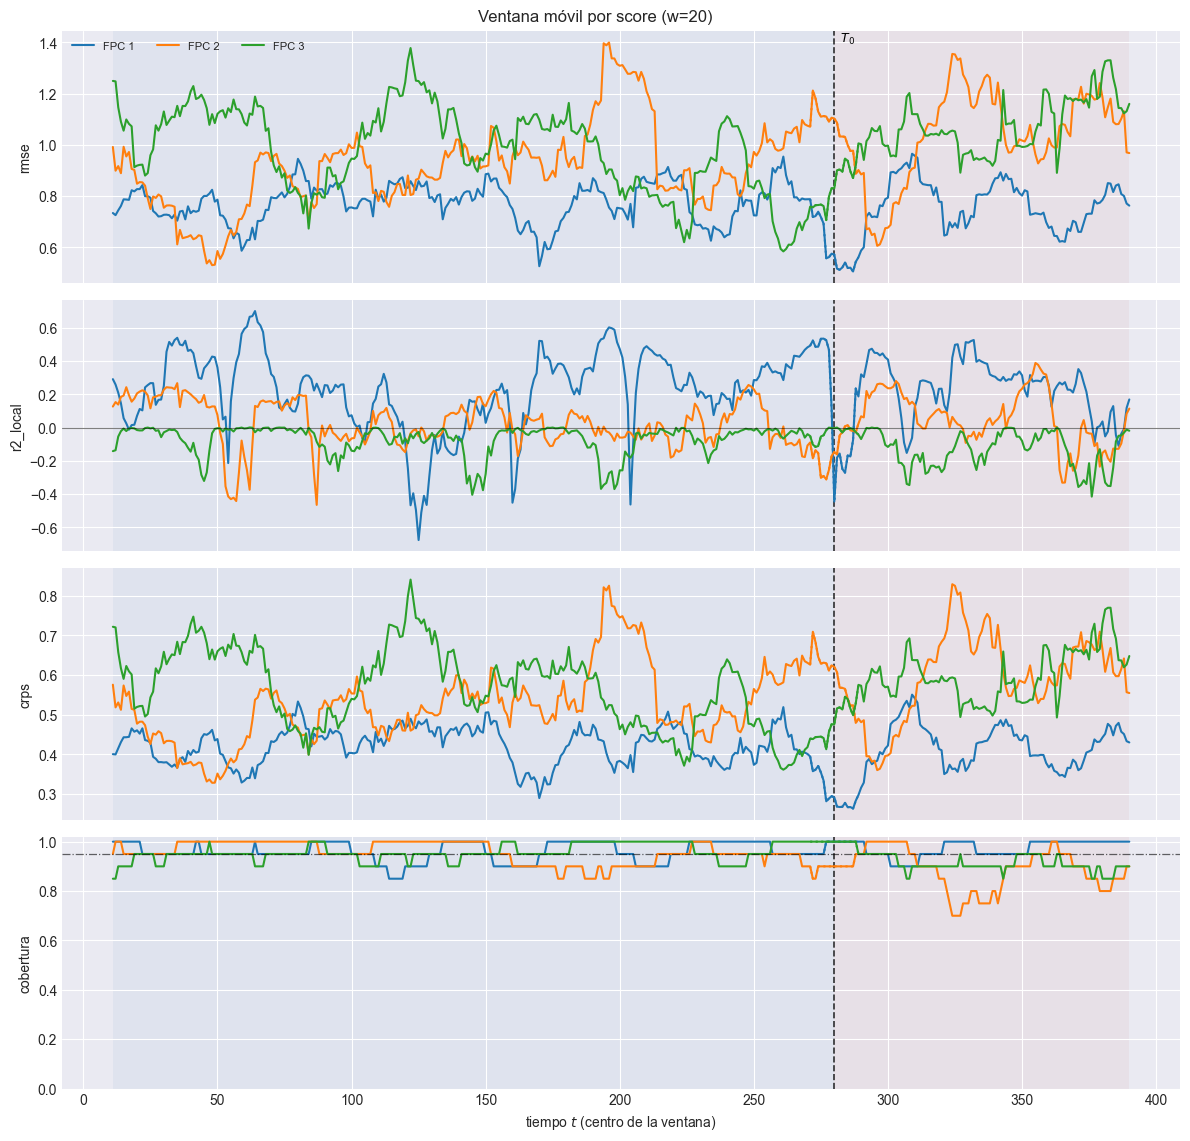

In [28]:
tablas_score = {
    w: ventana_movil_scores(
        Y_obs, Y_hat, T0_orig, w=w, muestras=SC_draws, li=li_s, ls=ls_s,
        t_offset=N_LAGS,
        etiquetas=[f"FPC {i + 1}" for i in COMPONENT_IDX])
    for w in VENTANAS_W
}
w_ref = VENTANAS_W[len(VENTANAS_W) // 2]
tablas_score[w_ref].to_csv(PATHS["out_report"] / f"57_ventana_scores_w{w_ref}.csv",
                           index=False)

plot_ventana_movil(
    tablas_score[w_ref], T0, ["rmse", "r2_local", "crps", "cobertura"],
    columna_grupo="componente",
    title=f"Ventana móvil por score (w={w_ref})",
    save_path=str(PATHS["out_report"] / "57_ventana_scores.png"))
plt.show()

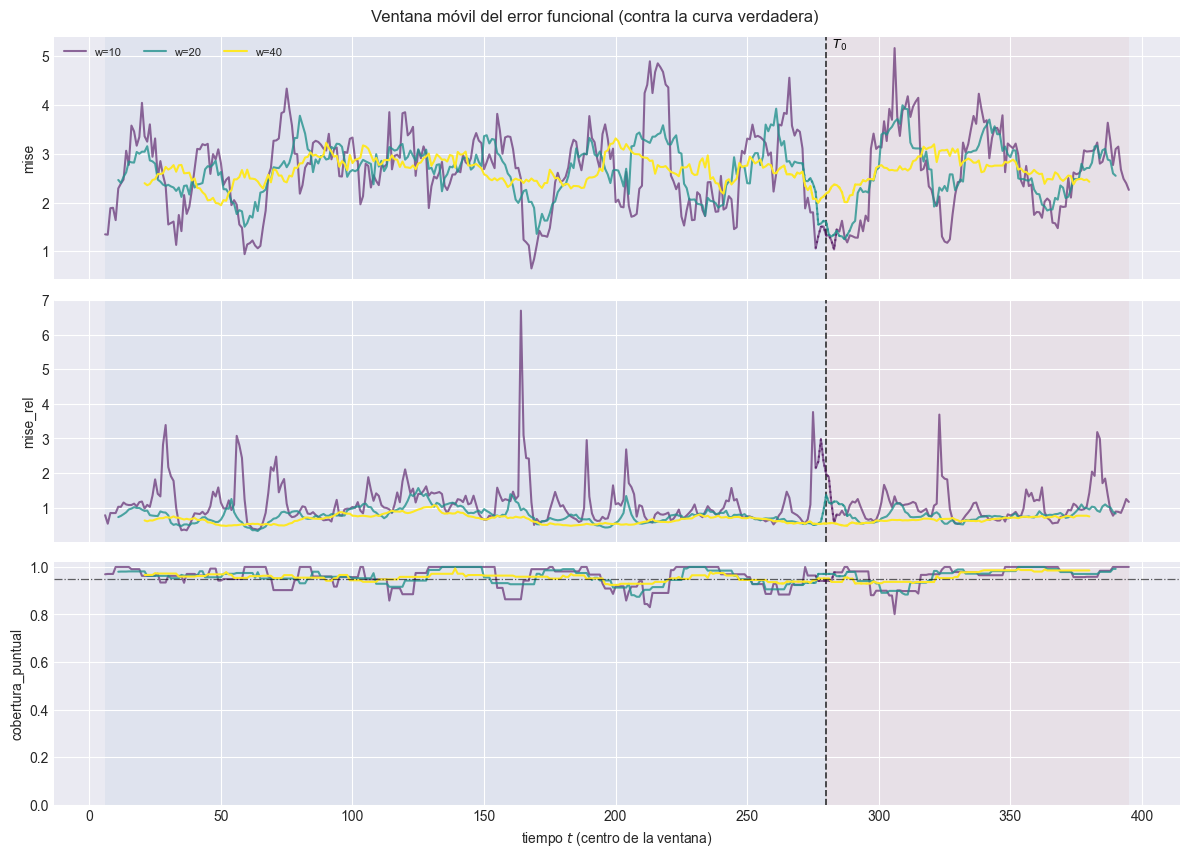

In [29]:
tablas_fun = {
    w: ventana_movil_funcional(X_true_ev, X_pred, grilla, T0_orig, w=w,
                               li=li_f, ls=ls_f, t_offset=N_LAGS)
    for w in VENTANAS_W
}
tablas_fun[w_ref].to_csv(PATHS["out_report"] / f"58_ventana_funcional_w{w_ref}.csv",
                         index=False)

plot_ventana_movil(
    tablas_fun[w_ref], T0, ["mise", "mise_rel", "cobertura_puntual"],
    tablas_por_w=tablas_fun,
    title="Ventana móvil del error funcional (contra la curva verdadera)",
    save_path=str(PATHS["out_report"] / "58_ventana_funcional.png"))
plt.show()

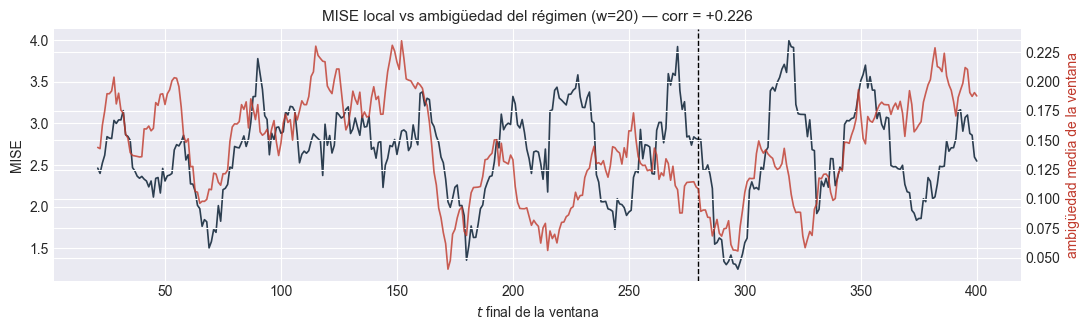

corr(MISE local, ambigüedad de la ventana) = +0.226
   Positiva ⇒ el error se concentra donde la condicional es genuinamente bimodal.


In [30]:
# El MISE local contra la ambigüedad media de la misma ventana. Si el error
# sigue a la ambigüedad, la variación a lo largo de la serie es una propiedad
# del mecanismo y no una degradación del modelo.
t_ref = tablas_fun[w_ref]
if HAY_P and "t_fin" in t_ref.columns:
    centro = t_ref["t_fin"].to_numpy()
    amb_ventana = np.array([
        np.nanmean(ambig[max(0, int(tf) - w_ref):int(tf)]) for tf in centro])
    _c = np.corrcoef(t_ref["mise"].to_numpy(), amb_ventana)[0, 1]

    fig, ax = plt.subplots(figsize=(11, 3.4))
    ax.plot(centro, t_ref["mise"], lw=1.2, color="#2c3e50", label="MISE local")
    ax2 = ax.twinx()
    ax2.plot(centro, amb_ventana, lw=1.2, color="#c0392b", alpha=0.8)
    ax.axvline(T0, color="k", ls="--", lw=1)
    ax.set_xlabel("$t$ final de la ventana"); ax.set_ylabel("MISE")
    ax2.set_ylabel("ambigüedad media de la ventana", color="#c0392b")
    ax.set_title(f"MISE local vs ambigüedad del régimen (w={w_ref}) — "
                 f"corr = {_c:+.3f}", fontsize=11)
    fig.tight_layout()
    fig.savefig(PATHS["out_report"] / "59_mise_vs_ambiguedad.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"corr(MISE local, ambigüedad de la ventana) = {_c:+.3f}")
    print("   Positiva ⇒ el error se concentra donde la condicional es "
          "genuinamente bimodal.")
else:
    print("Sin p_t disponible (o sin `t_fin` en la tabla); se omite la figura.")

In [31]:
# Lectura numérica del salto en T0, excluyendo las ventanas que lo cruzan.
print(f"{'w':>4}  {'MISE train':>11}  {'MISE test':>11}  {'salto':>7}")
print(f"{'─'*4}  {'─'*11}  {'─'*11}  {'─'*7}")
for w in VENTANAS_W:
    t_ = tablas_fun[w]
    limpio = t_[~t_["cruza_T0"]]
    a = limpio.loc[limpio.bloque == "train", "mise"].mean()
    b = limpio.loc[limpio.bloque == "test",  "mise"].mean()
    print(f"{w:>4}  {a:>11.6f}  {b:>11.6f}  {b/a:>6.2f}×")

_p_tr = (reg_ev[es_train] == 1).mean()
_p_te = (reg_ev[~es_train] == 1).mean()
print(f"\nproporción del {ETIQUETAS[1]}: train {_p_tr:.3f} · test {_p_te:.3f}")
print("   Si difieren mucho, parte del salto es composición de regímenes y no "
      "generalización.")

   w   MISE train    MISE test    salto
────  ───────────  ───────────  ───────
  10     2.676696     2.691409    1.01×
  20     2.683068     2.747449    1.02×
  40     2.664622     2.742002    1.03×

proporción del régimen 2: train 0.656 · test 0.617
   Si difieren mucho, parte del salto es composición de regímenes y no generalización.


## 8. Calibración marginal

Bajo calibración perfecta el PIT es uniforme. La **forma** dice qué falla: una
U indica bandas demasiado angostas, una campana demasiado anchas, y una
pendiente un sesgo del centro. Contrastar train contra test separa el desajuste
del modelo de la pérdida de calibración fuera de muestra.

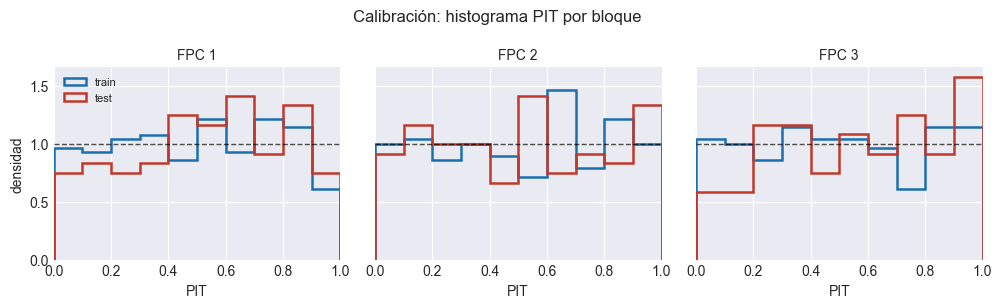

  FPC 1:  train KS=0.050 (aproximadamente uniforme)   test KS=0.081 (aproximadamente uniforme)
  FPC 2:  train KS=0.045 (aproximadamente uniforme)   test KS=0.054 (aproximadamente uniforme)
  FPC 3:  train KS=0.039 (aproximadamente uniforme)   test KS=0.102 (aproximadamente uniforme)


In [32]:
pit_tr = {f"FPC {COMPONENT_IDX[k]+1}": pit_muestral(Y_obs[es_train, k],
                                                    SC_draws[:, es_train, k])
          for k in range(n_components)}
pit_te = {f"FPC {COMPONENT_IDX[k]+1}": pit_muestral(Y_obs[~es_train, k],
                                                    SC_draws[:, ~es_train, k])
          for k in range(n_components)}

plot_calibracion_pit(pit_tr, pit_te,
                     save_path=str(PATHS["out_report"] / "60_pit.png"))
plt.show()

for nombre in pit_tr:
    d_tr, d_te = diagnostico_pit(pit_tr[nombre]), diagnostico_pit(pit_te[nombre])
    print(f"  {nombre}:  train KS={d_tr['ks']:.3f} ({d_tr['forma']})   "
          f"test KS={d_te['ks']:.3f} ({d_te['forma']})")

## 9. Calibración condicional al régimen verdadero

Eje 2 del diseño (`docs/03 Modelo.tex §03_06`). El estado verdadero es aquí
**discreto** —el régimen vigente— y se pasa directo a `cobertura_condicional`,
sin cuantilizar: no hay nada que dividir en terciles.

Qué esperar:

- **Cobertura ≈ nominal en ambos regímenes**: el modelo representa los dos, no
  sólo el dominante.
- **Cobertura que se desploma en el régimen minoritario**, con anchos
  parecidos: el modelo lo está tratando como ruido del régimen dominante. Es el
  modo de fallo característico de un modelo unimodal y la marginal lo esconde,
  porque el régimen dominante pesa más en el promedio.
- **Cobertura alta en ambos con anchos grandes**: calibración por exceso de
  ancho —la banda cubre las dos modas y todo lo que hay entre ellas—; el CRPS y
  el puntaje de energía por estrato lo penalizan y por eso se reportan junto a
  la cobertura.

In [33]:
filas_cc = []
for mask, etq_bloque in ((es_train, "train"), (~es_train, "test"),
                         (np.ones(n_orig, bool), "todo")):
    presentes = np.unique(reg_ev[mask])
    fs = cobertura_condicional(
        X_true_ev[mask], li_f[mask], ls_f[mask], reg_ev[mask],
        etiquetas=[ETIQUETAS[j] for j in presentes],
        tau=grilla, muestras=X_draws[:, mask, :])
    for f in fs:
        filas_cc.append({"bloque": etq_bloque, **f})

cc_df = pd.DataFrame(filas_cc).set_index(["bloque", "estrato"])
cc_df.to_csv(PATHS["out_report"] / "61_cobertura_condicional_funcional.csv")

display(cc_df.style
    .format({"cobertura": "{:.4f}", "ancho_medio": "{:.4f}",
             "desvio": "{:+.4f}", "energy": "{:.4f}"})
    .background_gradient(subset=["cobertura"], cmap="RdYlGn", vmin=0.80, vmax=1.0)
    .set_caption(f"Cobertura funcional al {NIVEL:.0%} por RÉGIMEN verdadero · "
                 "`desvio` = estrato − marginal"))

_te = cc_df.loc["test"]
print(f"cobertura marginal (test)   : "
      f"{fun_df.loc['test', f'Cob{int(NIVEL*100)}_puntual']:.4f}")
print(f"rango entre regímenes (test): "
      f"[{_te['cobertura'].min():.4f}, {_te['cobertura'].max():.4f}]   "
      f"amplitud {_te['cobertura'].max() - _te['cobertura'].min():.4f}")

_amp = _te["cobertura"].max() - _te["cobertura"].min()
print("\nVEREDICTO del eje 2: "
      + ("✓ cobertura estable entre regímenes" if _amp < 0.05 else
         "⚠ la cobertura depende del régimen: la marginal está compensando"))

cobertura marginal (test)   : 0.9677
rango entre regímenes (test): [0.9476, 0.9805]   amplitud 0.0329

VEREDICTO del eje 2: ✓ cobertura estable entre regímenes


In [34]:
# Cobertura condicional por SCORE, bloque de prueba
filas_cs = []
for k in range(n_components):
    m = ~es_train
    presentes = np.unique(reg_ev[m])
    fs = cobertura_condicional(
        Y_obs[m, k], li_s[m, k], ls_s[m, k], reg_ev[m],
        etiquetas=[ETIQUETAS[j] for j in presentes],
        muestras=SC_draws[:, m, k])
    for f in fs:
        filas_cs.append({"FPC": f"FPC {COMPONENT_IDX[k] + 1}", **f})

cs_df = pd.DataFrame(filas_cs).set_index(["FPC", "estrato"])
cs_df.to_csv(PATHS["out_report"] / "62_cobertura_condicional_scores.csv")

display(cs_df.style
    .format({"cobertura": "{:.4f}", "ancho_medio": "{:.4f}",
             "desvio": "{:+.4f}", "crps": "{:.4f}"})
    .background_gradient(subset=["cobertura"], cmap="RdYlGn", vmin=0.80, vmax=1.0)
    .set_caption("Cobertura por score y régimen · bloque de prueba"))

## 9.1 ¿Es bimodal la predictiva donde la condicional lo es?

**El resultado central de esta corrida**, y lo que ningún escenario anterior
podía medir.

In [35]:
if not HAY_P:
    print("Sin p_t disponible: se omite §9.1. Regenerar 13_01 para obtener "
          "10_estado_regimen.csv.")
else:
    def bimodalidad_sarle(x):
        """Coeficiente de Sarle b = (g1^2 + 1) / g2. Referencia: uniforme 5/9."""
        x = np.asarray(x, float)
        m = x - x.mean()
        m2 = (m ** 2).mean()
        if m2 <= 0:
            return np.nan
        g1 = (m ** 3).mean() / m2 ** 1.5
        g2 = (m ** 4).mean() / m2 ** 2
        return (g1 ** 2 + 1.0) / g2

    UMBRAL_AMB = 0.4     # ambiguedad > 0.4  ⇔  |p - 0.5| < 0.1
    es_amb  = amb_ev > UMBRAL_AMB
    es_det  = amb_ev < 0.1                       # p cerca de 0 o de 1
    k_sel   = K_SEP                              # componente que carga el régimen

    b_amb = np.array([bimodalidad_sarle(SC_draws[:, i, k_sel])
                      for i in np.where(es_amb)[0]])
    b_det = np.array([bimodalidad_sarle(SC_draws[:, i, k_sel])
                      for i in np.where(es_det)[0]])

    # Referencia: el b que daría la predictiva CORRECTA. Se construye una
    # mezcla 50/50 con los centros y la dispersión intra-régimen estimados del
    # bloque de entrenamiento, que es la ley condicional en un origen con
    # p = 1/2. Se recalcula por corrida: no depende de estos parámetros.
    _rng_ref = np.random.default_rng(SEED_PRED)
    _c_ref   = [Y_obs[es_train & (reg_ev == j), k_sel].mean() for j in range(J)]
    _s_ref   = float(np.mean([Y_obs[es_train & (reg_ev == j), k_sel].std()
                              for j in range(J)]))
    _u       = _rng_ref.random(S_total) < 0.5
    _muestra_ref = np.where(_u, _rng_ref.normal(_c_ref[0], _s_ref, S_total),
                                _rng_ref.normal(_c_ref[1], _s_ref, S_total))
    b_ref = bimodalidad_sarle(_muestra_ref)

    print(f"componente examinada: FPC {COMPONENT_IDX[k_sel]+1}")
    print(f"orígenes ambiguos (amb > {UMBRAL_AMB}): {es_amb.sum()}   "
          f"deterministas (amb < 0.1): {es_det.sum()}")
    print(f"\ncentros intra-régimen (train): {np.round(_c_ref, 3).tolist()}   "
          f"sd intra-régimen: {_s_ref:.3f}   "
          f"separación: {abs(_c_ref[1]-_c_ref[0])/_s_ref:.2f} sd")
    print(f"\ncoeficiente de Sarle, media:")
    print(f"  ambiguos                  : {np.nanmean(b_amb):.4f}")
    print(f"  deterministas             : {np.nanmean(b_det):.4f}")
    print(f"  b_ref (predictiva correcta): {b_ref:.4f}   ← la marca a alcanzar")
    print(f"  gaussiana = {1/3:.4f}   ·   uniforme 5/9 = {5/9:.4f} (umbral "
          f"clásico, conservador)")
    print(f"\nfracción de ambiguos que alcanza b_ref     : "
          f"{np.nanmean(b_amb >= b_ref):.2%}")
    print(f"fracción de deterministas que alcanza b_ref: "
          f"{np.nanmean(b_det >= b_ref):.2%}   (debería ser baja)")

    _delta = np.nanmean(b_amb) - np.nanmean(b_det)
    _frac_ref = float(np.nanmean(b_amb) / b_ref)
    print(f"\nb medio en ambiguos / b_ref = {_frac_ref:.2f}")
    print("VEREDICTO: "
          + ("✓ la predictiva se aplana o se desdobla donde la condicional es "
             "bimodal" if (_delta > 0.05 and _frac_ref > 0.8) else
             "⚠ la predictiva no alcanza la forma que la condicional verdadera "
             "tiene\n  en los orígenes ambiguos: la mezcla no está "
             "representando los dos regímenes"))

    pd.DataFrame({
        "grupo": ["ambiguos"] * len(b_amb) + ["deterministas"] * len(b_det),
        "sarle": np.concatenate([b_amb, b_det]),
    }).to_csv(PATHS["out_report"] / "63_bimodalidad_sarle.csv", index=False)

componente examinada: FPC 1
orígenes ambiguos (amb > 0.4): 47   deterministas (amb < 0.1): 210

centros intra-régimen (train): [1.221, -0.636]   sd intra-régimen: 0.462   separación: 4.02 sd

coeficiente de Sarle, media:
  ambiguos                  : 0.4534
  deterministas             : 0.4372
  b_ref (predictiva correcta): 0.5832   ← la marca a alcanzar
  gaussiana = 0.3333   ·   uniforme 5/9 = 0.5556 (umbral clásico, conservador)

fracción de ambiguos que alcanza b_ref     : 0.00%
fracción de deterministas que alcanza b_ref: 0.00%   (debería ser baja)

b medio en ambiguos / b_ref = 0.78
VEREDICTO: ⚠ la predictiva no alcanza la forma que la condicional verdadera tiene
  en los orígenes ambiguos: la mezcla no está representando los dos regímenes


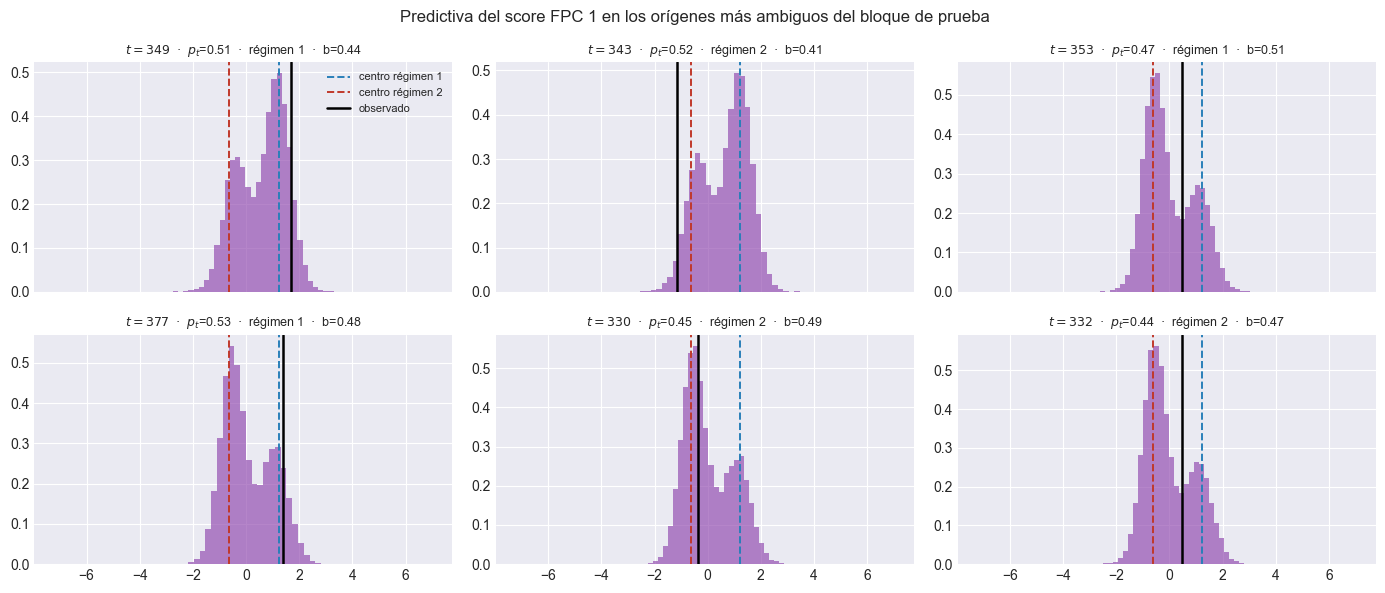

En orígenes ambiguos, por régimen efectivamente realizado:
  régimen 1    n= 23   media predicha +0.251   observada +1.144
  régimen 2    n= 24   media predicha +0.298   observada -0.291

En los orígenes ambiguos el modelo NO puede saber qué régimen saldrá: lo correcto
es una predictiva ancha o bimodal, no un centro que acierte. La comparación de
arriba mide cuánto de la separación observada logra anticipar el peso de la mezcla.


In [36]:
if HAY_P:
    # Densidades predictivas en los 6 orígenes MÁS ambiguos del bloque de prueba,
    # con la observación y los dos centros condicionales estimados desde train.
    idx_amb_te = idx_test[np.argsort(-amb_ev[idx_test])][:6]

    centros = [Y_obs[es_train & (reg_ev == j), K_SEP].mean() for j in range(J)]
    fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
    for ax, i in zip(axes.ravel(), idx_amb_te):
        z = SC_draws[:, i, K_SEP]
        ax.hist(z, bins=60, density=True, color="#8e44ad", alpha=0.65)
        for j, c in enumerate(centros):
            ax.axvline(c, color=["#2980b9", "#c0392b"][j], ls="--", lw=1.4,
                       label=f"centro {ETIQUETAS[j]}" if ax is axes[0, 0] else None)
        ax.axvline(Y_obs[i, K_SEP], color="k", lw=1.8,
                   label="observado" if ax is axes[0, 0] else None)
        ax.set_title(f"$t={t_orig[i]}$  ·  $p_t$={p_ev[i]:.2f}  ·  "
                     f"{ETIQUETAS[reg_ev[i]]}  ·  b={bimodalidad_sarle(z):.2f}",
                     fontsize=9)
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(f"Predictiva del score FPC {COMPONENT_IDX[K_SEP]+1} en los "
                 f"orígenes más ambiguos del bloque de prueba", fontsize=12)
    fig.tight_layout()
    fig.savefig(PATHS["out_report"] / "64_predictiva_bimodal.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    # Contraste directo: ¿la predictiva se desplaza CON el régimen realizado?
    print("En orígenes ambiguos, por régimen efectivamente realizado:")
    for j in range(J):
        m = es_amb & (reg_ev == j)
        if m.sum() > 0:
            print(f"  {ETIQUETAS[j]:<12} n={int(m.sum()):>3}   "
                  f"media predicha {Y_hat[m, K_SEP].mean():+.3f}   "
                  f"observada {Y_obs[m, K_SEP].mean():+.3f}")
    print("\nEn los orígenes ambiguos el modelo NO puede saber qué régimen "
          "saldrá: lo correcto\nes una predictiva ancha o bimodal, no un centro "
          "que acierte. La comparación de\narriba mide cuánto de la separación "
          "observada logra anticipar el peso de la mezcla.")

## 10. Comparación con las líneas base

In [37]:
_bl = PATHS["out_report"] / "30_baselines_test.csv"
rmse_psbp = met_df.loc["test", "RMSE"].mean()
print(f"RMSE promedio en scores — PSBP-FD (test): {rmse_psbp:.4f}\n")

if _bl.exists():
    baselines_df = pd.read_csv(_bl, index_col=0)
    display(baselines_df.style.format("{:.4f}", na_rep="—")
            .set_caption("Líneas base sobre el bloque de prueba (h=1)"))
    if "RMSE_scores_prom" in baselines_df.columns:
        for modelo, fila in baselines_df.iterrows():
            marca = "✓ PSBP mejor" if rmse_psbp < fila["RMSE_scores_prom"] else "✗ baseline mejor"
            print(f"  vs {modelo:24s} RMSE={fila['RMSE_scores_prom']:.4f}  → {marca}")
else:
    print("⚠ falta 30_baselines_test.csv — ejecuta 13_01 §6.")

print("\nLectura para el Escenario 3: a diferencia de la corrida 12, aquí "
      "ganar en RMSE sí\nes exigible —hay dependencia genuina en la media—. "
      "Pero el resultado que el\nescenario existe para producir es §9.1: "
      "ninguna línea base puede entregar una\npredictiva bimodal, y ésa es la "
      "diferencia cualitativa, no de grado.")
print("\nNota: sólo hay dos líneas base (media incondicional y persistencia). "
      "FAR(1),\nVAR sobre scores y ARIMA por score siguen pendientes en "
      "fit/baselines.py.")

RMSE promedio en scores — PSBP-FD (test): 0.9572



,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,120.0000,0.9865,1.1209,1.0747,1.0607,-0.0270,4.2252,2.0555
persistencia_lag1,120.0000,0.9137,1.2529,1.4171,1.1946,-0.3208,3.7588,1.9388


  vs media_incondicional      RMSE=1.0607  → ✓ PSBP mejor
  vs persistencia_lag1        RMSE=1.1946  → ✓ PSBP mejor

Lectura para el Escenario 3: a diferencia de la corrida 12, aquí ganar en RMSE sí
es exigible —hay dependencia genuina en la media—. Pero el resultado que el
escenario existe para producir es §9.1: ninguna línea base puede entregar una
predictiva bimodal, y ésa es la diferencia cualitativa, no de grado.

Nota: sólo hay dos líneas base (media incondicional y persistencia). FAR(1),
VAR sobre scores y ARIMA por score siguen pendientes en fit/baselines.py.


In [38]:
# ── Resumen ejecutable del experimento ───────────────────────────────────────
_te = cc_df.loc["test"]
resumen = {
    "experiment_id": EXPERIMENT_ID,
    "escenario_id": int(ESCENARIO_ID),
    "objetivo_evaluacion": OBJETIVO,
    "modo_residuo": MODO_RESIDUO,
    "nivel": NIVEL,
    "S_scores": int(S_total), "S_funcional": int(X_draws.shape[0]),
    "rmse_scores_train": float(met_df.loc["train", "RMSE"].mean()),
    "rmse_scores_test":  float(met_df.loc["test", "RMSE"].mean()),
    "r2_scores_test":    float(met_df.loc["test", "R2"].mean()),
    "crps_scores_test":  float(met_df.loc["test", "CRPS"].mean()),
    "mise_train": float(fun_df.loc["train", "MISE"]),
    "mise_test":  float(fun_df.loc["test", "MISE"]),
    "mise_truncamiento_test": float(fun_df.loc["test", "MISE_truncamiento"]),
    "energy_test": float(fun_df.loc["test", "energy"]),
    "cobertura_puntual_test": float(fun_df.loc["test", f"Cob{int(NIVEL*100)}_puntual"]),
    # Eje 2
    "cobertura_regimen_1": float(_te["cobertura"].iloc[0]),
    "cobertura_regimen_2": float(_te["cobertura"].iloc[-1]),
    "amplitud_cobertura_regimenes": float(_te["cobertura"].max() - _te["cobertura"].min()),
    # Bimodalidad
    "fpc_regimen": int(COMPONENT_IDX[K_SEP] + 1),
    "sarle_ambiguos":      float(np.nanmean(b_amb)) if HAY_P else None,
    "sarle_deterministas": float(np.nanmean(b_det)) if HAY_P else None,
    "sarle_referencia":    float(b_ref) if HAY_P else None,
}
pd.Series(resumen).to_csv(PATHS["out_report"] / "65_resumen.csv", header=False)
for k, v in resumen.items():
    print(f"  {k:30s}: {v}")
print(f"\nFiguras y tablas en {PATHS['out_report']}")

  experiment_id                 : escenario_3_r01
  escenario_id                  : 3
  objetivo_evaluacion           : curva_verdadera
  modo_residuo                  : ninguno
  nivel                         : 0.95
  S_scores                      : 45000
  S_funcional                   : 500
  rmse_scores_train             : 0.9035016040441647
  rmse_scores_test              : 0.9571914922785117
  r2_scores_test                : 0.16031877007349396
  crps_scores_test              : 0.5324646703430497
  mise_train                    : 2.6317958211645194
  mise_test                     : 2.603603620042457
  mise_truncamiento_test        : 0.005480151491580717
  energy_test                   : 8.141946402448314
  cobertura_puntual_test        : 0.9676666666666667
  cobertura_regimen_1           : 0.9475616921269095
  cobertura_regimen_2           : 0.9804601899196494
  amplitud_cobertura_regimenes  : 0.0328984977927399
  fpc_regimen                   : 1
  sarle_ambiguos                